In [26]:
# ============================================================
# Install Required Libraries
# ============================================================

!pip install -q kaggle nibabel segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 5.3 MB/s eta 0:00:00


In [1]:
# ============================================================
# Kaggle Authentication
# ============================================================

from google.colab import userdata
import os

os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"] = userdata.get("api")

In [2]:
# ============================================================
# Download BraTS 2019 Dataset
# ============================================================

!kaggle datasets download -d aryashah2k/brain-tumor-segmentation-brats-2019

Dataset URL: https://www.kaggle.com/datasets/aryashah2k/brain-tumor-segmentation-brats-2019
License(s): CC0-1.0
100% 2.60G/2.60G [00:24<00:00, 115MB/s]



In [3]:
import zipfile
import os

# Define the path to the downloaded zip file
zip_file_path = "/content/brain-tumor-segmentation-brats-2019.zip"

# Define the directory where the contents will be extracted
extraction_path = "/content/brats"

# Create the extraction directory if it doesn't exist
os.makedirs(extraction_path, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extraction_path)

print(f"Dataset unzipped to: {extraction_path}")

Dataset unzipped to: /content/brats


In [4]:
# ============================================================
# Explore Dataset Structure
# ============================================================

import os

for root, dirs, files in os.walk("/content/brats"):
    level = root.replace("/content/brats", "").count(os.sep)

    if level > 2:
        continue

    print(root)
    print("Files:", files[:5])
    print()
# ============================================================
# Count Files
# ============================================================

for root, dirs, files in os.walk("/content/brats"):
    if files:
        print(root, len(files))

/content/brats
Files: []

/content/brats/MICCAI_BraTS_2019_Data_Training
Files: ['name_mapping.csv', 'survival_data.csv']

/content/brats/MICCAI_BraTS_2019_Data_Training/LGG
Files: []

/content/brats/MICCAI_BraTS_2019_Data_Training/HGG
Files: []

/content/brats/MICCAI_BraTS_2019_Data_Training 2
/content/brats/MICCAI_BraTS_2019_Data_Training/LGG/BraTS19_TCIA12_101_1 5
/content/brats/MICCAI_BraTS_2019_Data_Training/LGG/BraTS19_TCIA10_330_1 5
/content/brats/MICCAI_BraTS_2019_Data_Training/LGG/BraTS19_TCIA09_177_1 5
/content/brats/MICCAI_BraTS_2019_Data_Training/LGG/BraTS19_2013_16_1 5
/content/brats/MICCAI_BraTS_2019_Data_Training/LGG/BraTS19_TCIA09_462_1 5
/content/brats/MICCAI_BraTS_2019_Data_Training/LGG/BraTS19_2013_29_1 5
/content/brats/MICCAI_BraTS_2019_Data_Training/LGG/BraTS19_2013_15_1 5
/content/brats/MICCAI_BraTS_2019_Data_Training/LGG/BraTS19_TCIA10_310_1 5
/content/brats/MICCAI_BraTS_2019_Data_Training/LGG/BraTS19_TCIA10_637_1 5
/content/brats/MICCAI_BraTS_2019_Data_Training/

In [5]:
# ============================================================
# Read NIfTI File
# ============================================================

import nibabel as nib

# Using an example path from the extracted dataset. You can change this to any other .nii file.
# The original path caused a FileNotFoundError, so an existing HGG flair file is used.
image = nib.load("/content/brats/MICCAI_BraTS_2019_Data_Training/HGG/BraTS19_TCIA02_455_1/BraTS19_TCIA02_455_1_flair.nii")

volume = image.get_fdata()

print("Shape:", volume.shape)
print("Data type:", volume.dtype)

Shape: (240, 240, 155)
Data type: float64


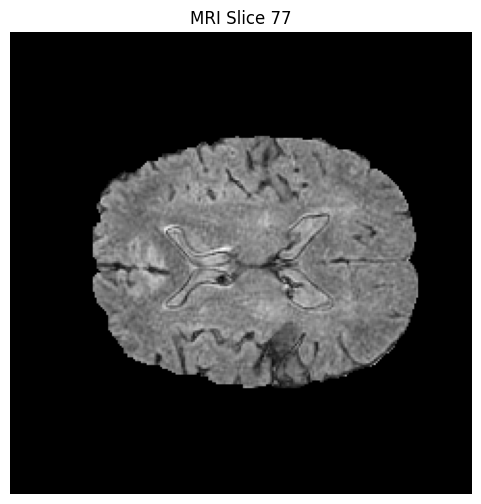

In [6]:
# ============================================================
# Phase 2: Visualize MRI Slices
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Select the middle slice
slice_index = volume.shape[2] // 2

plt.figure(figsize=(6, 6))

plt.imshow(
    volume[:, :, slice_index],
    cmap="gray"
)

plt.title(f"MRI Slice {slice_index}")
plt.axis("off")

plt.show()

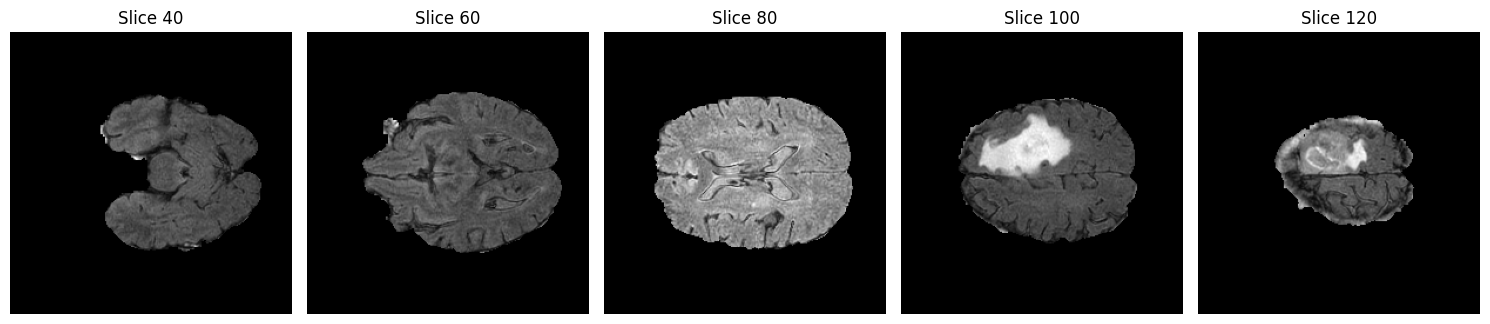

In [7]:
# ============================================================
# Visualize Multiple MRI Slices
# ============================================================

slice_indices = [40, 60, 80, 100, 120]

plt.figure(figsize=(15, 4))

for i, idx in enumerate(slice_indices):

    plt.subplot(1, 5, i + 1)

    plt.imshow(
        volume[:, :, idx],
        cmap="gray"
    )

    plt.title(f"Slice {idx}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [8]:
# ============================================================
# Find MRI and Segmentation Files
# ============================================================

import os

for root, dirs, files in os.walk("/content/brats"):

    nii_files = [
        f for f in files
        if f.endswith(".nii") or f.endswith(".nii.gz")
    ]

    if nii_files:

        print("\nFolder:", root)

        for file in nii_files:
            print("  ", file)


Folder: /content/brats/MICCAI_BraTS_2019_Data_Training/LGG/BraTS19_TCIA12_101_1
   BraTS19_TCIA12_101_1_t1.nii
   BraTS19_TCIA12_101_1_t1ce.nii
   BraTS19_TCIA12_101_1_flair.nii
   BraTS19_TCIA12_101_1_seg.nii
   BraTS19_TCIA12_101_1_t2.nii

Folder: /content/brats/MICCAI_BraTS_2019_Data_Training/LGG/BraTS19_TCIA10_330_1
   BraTS19_TCIA10_330_1_t2.nii
   BraTS19_TCIA10_330_1_t1ce.nii
   BraTS19_TCIA10_330_1_t1.nii
   BraTS19_TCIA10_330_1_flair.nii
   BraTS19_TCIA10_330_1_seg.nii

Folder: /content/brats/MICCAI_BraTS_2019_Data_Training/LGG/BraTS19_TCIA09_177_1
   BraTS19_TCIA09_177_1_t2.nii
   BraTS19_TCIA09_177_1_seg.nii
   BraTS19_TCIA09_177_1_flair.nii
   BraTS19_TCIA09_177_1_t1.nii
   BraTS19_TCIA09_177_1_t1ce.nii

Folder: /content/brats/MICCAI_BraTS_2019_Data_Training/LGG/BraTS19_2013_16_1
   BraTS19_2013_16_1_seg.nii
   BraTS19_2013_16_1_t2.nii
   BraTS19_2013_16_1_t1ce.nii
   BraTS19_2013_16_1_t1.nii
   BraTS19_2013_16_1_flair.nii

Folder: /content/brats/MICCAI_BraTS_2019_Data_Tra

In [9]:
# Define the path to the segmentation mask for the loaded image
# This path corresponds to the 'seg' file for the HGG flair image loaded previously.
SEGMENTATION_PATH = "/content/brats/MICCAI_BraTS_2019_Data_Training/HGG/BraTS19_TCIA02_455_1/BraTS19_TCIA02_455_1_seg.nii"

In [10]:
# ============================================================
# Load Tumor Segmentation Mask
# ============================================================

seg_img = nib.load(SEGMENTATION_PATH)

mask = seg_img.get_fdata()

print("Mask shape:", mask.shape)
print("Mask data type:", mask.dtype)
print("Unique labels:", np.unique(mask))

Mask shape: (240, 240, 155)
Mask data type: float64
Unique labels: [0. 1. 2. 4.]


In [11]:
# ============================================================
# Phase 3: Convert Segmentation Mask to Binary Mask
# ============================================================

binary_mask = np.where(mask > 0, 1, 0)

print("Original labels:", np.unique(mask))
print("Binary labels:", np.unique(binary_mask))

Original labels: [0. 1. 2. 4.]
Binary labels: [0 1]


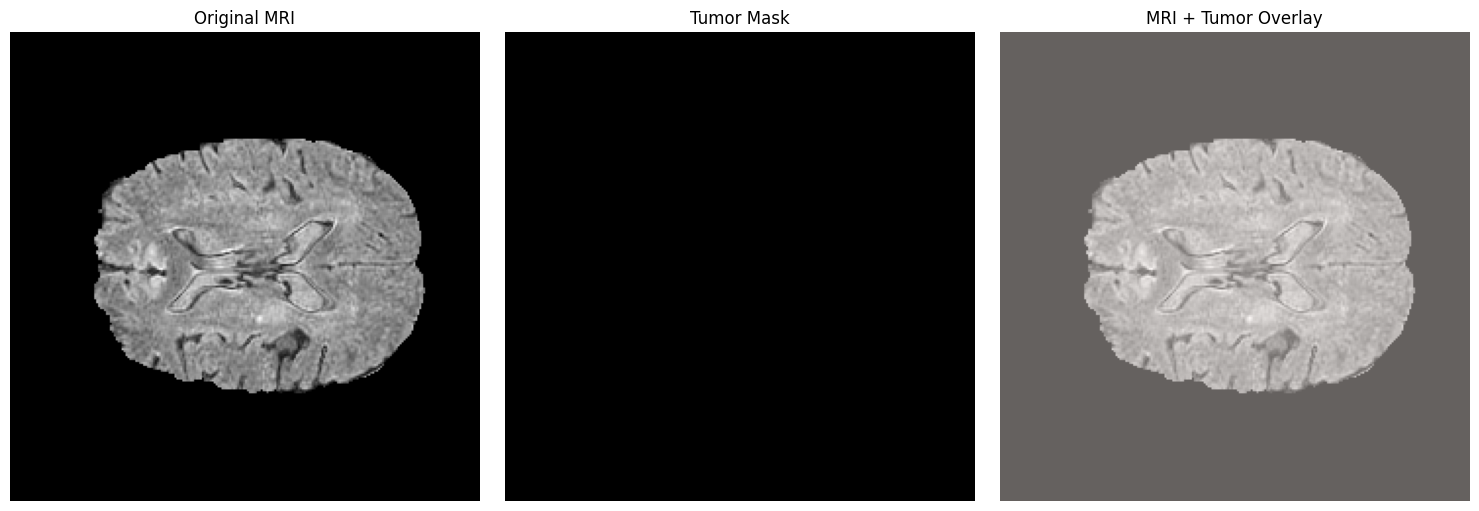

In [12]:
# ============================================================
# Phase 4: Visualize MRI and Tumor Mask
# ============================================================

slice_index = 80

mri_slice = volume[:, :, slice_index]
mask_slice = binary_mask[:, :, slice_index]

plt.figure(figsize=(15, 5))

# ------------------------------------------------------------
# Original MRI
# ------------------------------------------------------------

plt.subplot(1, 3, 1)

plt.imshow(
    mri_slice,
    cmap="gray"
)

plt.title("Original MRI")
plt.axis("off")


# ------------------------------------------------------------
# Tumor Mask
# ------------------------------------------------------------

plt.subplot(1, 3, 2)

plt.imshow(
    mask_slice,
    cmap="gray"
)

plt.title("Tumor Mask")
plt.axis("off")


# ------------------------------------------------------------
# MRI + Mask Overlay
# ------------------------------------------------------------

plt.subplot(1, 3, 3)

plt.imshow(
    mri_slice,
    cmap="gray"
)

plt.imshow(
    mask_slice,
    cmap="Reds",
    alpha=0.4
)

plt.title("MRI + Tumor Overlay")
plt.axis("off")


plt.tight_layout()
plt.show()

In [13]:
# ============================================================
# Phase 5: Find Slices Containing Tumor
# ============================================================

tumor_slices = []

for i in range(binary_mask.shape[2]):

    if np.sum(binary_mask[:, :, i]) > 0:
        tumor_slices.append(i)

print("Total slices:", binary_mask.shape[2])
print("Slices containing tumor:", len(tumor_slices))
print("Tumor slice indices:", tumor_slices[:20])

Total slices: 155
Slices containing tumor: 52
Tumor slice indices: [83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102]


In [14]:
# ============================================================
# Phase 6: Find All Patient Folders
# ============================================================

import os

DATASET_PATH = "/content/brats"

patient_folders = []

for root, dirs, files in os.walk(DATASET_PATH):

    nii_files = [
        f for f in files
        if f.endswith(".nii") or f.endswith(".nii.gz")
    ]

    # A patient folder should contain MRI/segmentation files
    if nii_files:
        patient_folders.append(root)

print("Number of folders containing MRI files:", len(patient_folders))

print("\nFirst 5 folders:")
for folder in patient_folders[:5]:
    print(folder)

Number of folders containing MRI files: 335

First 5 folders:
/content/brats/MICCAI_BraTS_2019_Data_Training/LGG/BraTS19_TCIA12_101_1
/content/brats/MICCAI_BraTS_2019_Data_Training/LGG/BraTS19_TCIA10_330_1
/content/brats/MICCAI_BraTS_2019_Data_Training/LGG/BraTS19_TCIA09_177_1
/content/brats/MICCAI_BraTS_2019_Data_Training/LGG/BraTS19_2013_16_1
/content/brats/MICCAI_BraTS_2019_Data_Training/LGG/BraTS19_TCIA09_462_1


In [15]:
# ============================================================
# Inspect First Patient
# ============================================================

first_patient = patient_folders[0]

print("Patient folder:")
print(first_patient)

print("\nFiles:")

for file in os.listdir(first_patient):
    print(file)

Patient folder:
/content/brats/MICCAI_BraTS_2019_Data_Training/LGG/BraTS19_TCIA12_101_1

Files:
BraTS19_TCIA12_101_1_t1.nii
BraTS19_TCIA12_101_1_t1ce.nii
BraTS19_TCIA12_101_1_flair.nii
BraTS19_TCIA12_101_1_seg.nii
BraTS19_TCIA12_101_1_t2.nii


In [16]:
# ============================================================
# Phase 7: Prepare Patient Dataset
# ============================================================

import os
import random
import numpy as np
import nibabel as nib

DATASET_PATH = "/content/brats/MICCAI_BraTS_2019_Data_Training"

# ------------------------------------------------------------
# Collect patient folders
# ------------------------------------------------------------

patient_folders = []

for root, dirs, files in os.walk(DATASET_PATH):

    if any(file.endswith("_flair.nii") for file in files):
        patient_folders.append(root)

patient_folders = sorted(patient_folders)

print("Total patients:", len(patient_folders))

Total patients: 335


In [17]:
# ============================================================
# Patient-Level Train / Validation / Test Split
# ============================================================

from sklearn.model_selection import train_test_split

# First split: 70% train, 30% temporary
train_patients, temp_patients = train_test_split(
    patient_folders,
    test_size=0.30,
    random_state=42
)

# Second split: temporary into 15% validation and 15% test
val_patients, test_patients = train_test_split(
    temp_patients,
    test_size=0.50,
    random_state=42
)

print("Training patients:", len(train_patients))
print("Validation patients:", len(val_patients))
print("Testing patients:", len(test_patients))

Training patients: 234
Validation patients: 50
Testing patients: 51


In [18]:
# ============================================================
# Create Slice Index
# ============================================================

def create_slice_index(patient_list, include_empty=True):

    slice_index = []

    for patient_path in patient_list:

        patient_name = os.path.basename(patient_path)

        flair_path = os.path.join(
            patient_path,
            f"{patient_name}_flair.nii"
        )

        seg_path = os.path.join(
            patient_path,
            f"{patient_name}_seg.nii"
        )

        # Load segmentation
        seg = nib.load(seg_path).get_fdata()

        # Convert to binary mask
        binary_seg = (seg > 0).astype(np.uint8)

        # Find tumor-containing slices
        tumor_slices = []

        for slice_idx in range(binary_seg.shape[2]):

            if np.sum(binary_seg[:, :, slice_idx]) > 0:
                tumor_slices.append(slice_idx)

        # Add tumor slices
        for slice_idx in tumor_slices:

            slice_index.append({
                "patient": patient_path,
                "flair": flair_path,
                "seg": seg_path,
                "slice": slice_idx,
                "has_tumor": 1
            })

        # ----------------------------------------------------
        # Add some empty slices
        # ----------------------------------------------------

        if include_empty:

            empty_slices = [
                i for i in range(binary_seg.shape[2])
                if i not in tumor_slices
            ]

            # Keep at most the same number of empty
            # slices as tumor slices
            random.seed(42)

            num_empty = min(
                len(empty_slices),
                len(tumor_slices)
            )

            selected_empty = random.sample(
                empty_slices,
                num_empty
            )

            for slice_idx in selected_empty:

                slice_index.append({
                    "patient": patient_path,
                    "flair": flair_path,
                    "seg": seg_path,
                    "slice": slice_idx,
                    "has_tumor": 0
                })

    return slice_index

In [19]:
# ============================================================
# Generate Slice Indices
# ============================================================

train_index = create_slice_index(train_patients)

val_index = create_slice_index(val_patients)

test_index = create_slice_index(test_patients)

print("Training slices:", len(train_index))
print("Validation slices:", len(val_index))
print("Testing slices:", len(test_index))

Training slices: 30061
Validation slices: 6726
Testing slices: 6332


In [20]:
# ============================================================
# Check Tumor / Non-Tumor Slice Distribution
# ============================================================

def count_labels(index):

    tumor = sum(
        item["has_tumor"] == 1
        for item in index
    )

    non_tumor = sum(
        item["has_tumor"] == 0
        for item in index
    )

    return tumor, non_tumor


train_tumor, train_non_tumor = count_labels(train_index)
val_tumor, val_non_tumor = count_labels(val_index)
test_tumor, test_non_tumor = count_labels(test_index)

print("TRAIN")
print("Tumor:", train_tumor)
print("Non-tumor:", train_non_tumor)

print("\nVALIDATION")
print("Tumor:", val_tumor)
print("Non-tumor:", val_non_tumor)

print("\nTEST")
print("Tumor:", test_tumor)
print("Non-tumor:", test_non_tumor)

TRAIN
Tumor: 15420
Non-tumor: 14641

VALIDATION
Tumor: 3501
Non-tumor: 3225

TEST
Tumor: 3229
Non-tumor: 3103


In [21]:
# ============================================================
# Phase 8: PyTorch Dataset
# ============================================================

import torch
from torch.utils.data import Dataset, DataLoader
import cv2
import numpy as np
import nibabel as nib

# ============================================================
# Brain Tumor Dataset
# ============================================================

class BrainTumorDataset(Dataset):

    def __init__(
        self,
        slice_index,
        image_size=256
    ):

        self.slice_index = slice_index
        self.image_size = image_size

    def __len__(self):

        return len(self.slice_index)

    def __getitem__(self, idx):

        item = self.slice_index[idx]

        # ----------------------------------------------------
        # Load MRI volume
        # ----------------------------------------------------

        flair_volume = nib.load(
            item["flair"]
        ).get_fdata()

        # ----------------------------------------------------
        # Load segmentation volume
        # ----------------------------------------------------

        seg_volume = nib.load(
            item["seg"]
        ).get_fdata()

        # ----------------------------------------------------
        # Select 2D slice
        # ----------------------------------------------------

        slice_idx = item["slice"]

        image = flair_volume[:, :, slice_idx]

        mask = seg_volume[:, :, slice_idx]

        # ----------------------------------------------------
        # Convert mask to binary
        # ----------------------------------------------------

        mask = (mask > 0).astype(np.float32)

        # ----------------------------------------------------
        # Normalize MRI
        # ----------------------------------------------------

        image = image.astype(np.float32)

        if image.max() > 0:

            image = (
                image - image.min()
            ) / (
                image.max() - image.min()
            )

        # ----------------------------------------------------
        # Resize
        # ----------------------------------------------------

        image = cv2.resize(
            image,
            (self.image_size, self.image_size),
            interpolation=cv2.INTER_AREA
        )

        mask = cv2.resize(
            mask,
            (self.image_size, self.image_size),
            interpolation=cv2.INTER_NEAREST
        )

        # ----------------------------------------------------
        # Convert to PyTorch tensors
        # ----------------------------------------------------

        image = torch.tensor(
            image,
            dtype=torch.float32
        )

        mask = torch.tensor(
            mask,
            dtype=torch.float32
        )

        # ----------------------------------------------------
        # Add channel dimension
        # ----------------------------------------------------

        image = image.unsqueeze(0)

        mask = mask.unsqueeze(0)

        return image, mask

In [22]:
# ============================================================
# Create Dataset Objects
# ============================================================

train_dataset = BrainTumorDataset(
    train_index
)

val_dataset = BrainTumorDataset(
    val_index
)

test_dataset = BrainTumorDataset(
    test_index
)

print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Testing samples:", len(test_dataset))

Training samples: 30061
Validation samples: 6726
Testing samples: 6332


In [23]:
# ============================================================
# Create DataLoaders
# ============================================================

BATCH_SIZE = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [24]:
# ============================================================
# Test DataLoader
# ============================================================

images, masks = next(iter(train_loader))

print("Images shape:", images.shape)
print("Masks shape:", masks.shape)

print("Image dtype:", images.dtype)
print("Mask dtype:", masks.dtype)

print("Image min:", images.min().item())
print("Image max:", images.max().item())

print("Mask unique values:", torch.unique(masks))

Images shape: torch.Size([16, 1, 256, 256])
Masks shape: torch.Size([16, 1, 256, 256])
Image dtype: torch.float32
Mask dtype: torch.float32
Image min: 0.0
Image max: 0.99837726354599
Mask unique values: tensor([0., 1.])


In [27]:
# ============================================================
# Phase 13: U-Net Model
# ============================================================

import torch
import segmentation_models_pytorch as smp

# ------------------------------------------------------------
# Select device
# ------------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

# ------------------------------------------------------------
# Create U-Net
# ------------------------------------------------------------

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=1,
    classes=1
)

model = model.to(device)

print(model)

Device: cuda


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 87.3MB            

model.safetensors: downloading bytes:           |  0.00B            

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

In [28]:
# ============================================================
# Phase 14: Loss Function
# ============================================================

dice_loss = smp.losses.DiceLoss(
    mode="binary",
    from_logits=True
)

bce_loss = smp.losses.SoftBCEWithLogitsLoss()

def loss_function(predictions, targets):

    dice = dice_loss(
        predictions,
        targets
    )

    bce = bce_loss(
        predictions,
        targets
    )

    return dice + bce

In [29]:
# ============================================================
# Optimizer
# ============================================================

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)
NUM_EPOCHS = 10

In [30]:
# ============================================================
# Dice Score
# ============================================================

def dice_score(predictions, targets, threshold=0.5):

    predictions = torch.sigmoid(predictions)

    predictions = (
        predictions > threshold
    ).float()

    smooth = 1e-6

    intersection = (
        predictions * targets
    ).sum(dim=(1, 2, 3))

    union = (
        predictions.sum(dim=(1, 2, 3))
        +
        targets.sum(dim=(1, 2, 3))
    )

    dice = (
        (2 * intersection + smooth)
        /
        (union + smooth)
    )

    return dice.mean()

In [31]:
# ============================================================
# IoU Score
# ============================================================

def iou_score(predictions, targets, threshold=0.5):

    predictions = torch.sigmoid(predictions)

    predictions = (
        predictions > threshold
    ).float()

    smooth = 1e-6

    intersection = (
        predictions * targets
    ).sum(dim=(1, 2, 3))

    union = (
        predictions + targets
        - predictions * targets
    ).sum(dim=(1, 2, 3))

    iou = (
        (intersection + smooth)
        /
        (union + smooth)
    )

    return iou.mean()

In [32]:
# ============================================================
# Test Forward Pass
# ============================================================

images, masks = next(iter(train_loader))

images = images.to(device)
masks = masks.to(device)

with torch.no_grad():

    predictions = model(images)

print("Input shape:", images.shape)
print("Output shape:", predictions.shape)

Input shape: torch.Size([16, 1, 256, 256])
Output shape: torch.Size([16, 1, 256, 256])


In [33]:
loss = loss_function(
    predictions,
    masks
)

print("Initial loss:", loss.item())
dice = dice_score(
    predictions,
    masks
)

iou = iou_score(
    predictions,
    masks
)

print("Initial Dice:", dice.item())
print("Initial IoU:", iou.item())

Initial loss: 1.6007338762283325
Initial Dice: 0.028881173580884933
Initial IoU: 0.015018034726381302


In [34]:
# ============================================================
# Phase 18: Training Loop
# ============================================================

import time

NUM_EPOCHS = 10

best_val_dice = 0.0

train_losses = []
val_losses = []
val_dice_scores = []
val_iou_scores = []


for epoch in range(NUM_EPOCHS):

    start_time = time.time()

    # ========================================================
    # TRAINING
    # ========================================================

    model.train()

    running_train_loss = 0.0

    for images, masks in train_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        masks = masks.to(
            device,
            non_blocking=True
        )

        # ----------------------------------------------------
        # Clear gradients
        # ----------------------------------------------------

        optimizer.zero_grad()

        # ----------------------------------------------------
        # Forward pass
        # ----------------------------------------------------

        predictions = model(images)

        # ----------------------------------------------------
        # Calculate loss
        # ----------------------------------------------------

        loss = loss_function(
            predictions,
            masks
        )

        # ----------------------------------------------------
        # Backpropagation
        # ----------------------------------------------------

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()

    # Average training loss

    epoch_train_loss = (
        running_train_loss
        /
        len(train_loader)
    )


    # ========================================================
    # VALIDATION
    # ========================================================

    model.eval()

    running_val_loss = 0.0
    running_val_dice = 0.0
    running_val_iou = 0.0

    with torch.no_grad():

        for images, masks in val_loader:

            images = images.to(
                device,
                non_blocking=True
            )

            masks = masks.to(
                device,
                non_blocking=True
            )

            # ------------------------------------------------
            # Prediction
            # ------------------------------------------------

            predictions = model(images)

            # ------------------------------------------------
            # Loss
            # ------------------------------------------------

            loss = loss_function(
                predictions,
                masks
            )

            # ------------------------------------------------
            # Metrics
            # ------------------------------------------------

            dice = dice_score(
                predictions,
                masks
            )

            iou = iou_score(
                predictions,
                masks
            )

            running_val_loss += loss.item()

            running_val_dice += dice.item()

            running_val_iou += iou.item()


    # Average validation metrics

    epoch_val_loss = (
        running_val_loss
        /
        len(val_loader)
    )

    epoch_val_dice = (
        running_val_dice
        /
        len(val_loader)
    )

    epoch_val_iou = (
        running_val_iou
        /
        len(val_loader)
    )


    # ========================================================
    # Store Results
    # ========================================================

    train_losses.append(
        epoch_train_loss
    )

    val_losses.append(
        epoch_val_loss
    )

    val_dice_scores.append(
        epoch_val_dice
    )

    val_iou_scores.append(
        epoch_val_iou
    )


    # ========================================================
    # Save Best Model
    # ========================================================

    if epoch_val_dice > best_val_dice:

        best_val_dice = epoch_val_dice

        torch.save(
            model.state_dict(),
            "best_brain_tumor_unet.pth"
        )

        best_marker = " ⭐ Best"

    else:

        best_marker = ""


    # ========================================================
    # Epoch Summary
    # ========================================================

    epoch_time = time.time() - start_time

    print(
        f"Epoch [{epoch + 1}/{NUM_EPOCHS}] "
        f"| Train Loss: {epoch_train_loss:.4f} "
        f"| Val Loss: {epoch_val_loss:.4f} "
        f"| Val Dice: {epoch_val_dice:.4f} "
        f"| Val IoU: {epoch_val_iou:.4f} "
        f"| Time: {epoch_time:.1f}s"
        f"{best_marker}"
    )

Epoch [1/10] | Train Loss: 0.3703 | Val Loss: 0.2233 | Val Dice: 0.8438 | Val IoU: 0.8044 | Time: 1467.0s ⭐ Best
Epoch [2/10] | Train Loss: 0.1136 | Val Loss: 0.2206 | Val Dice: 0.8337 | Val IoU: 0.7947 | Time: 1458.1s
Epoch [3/10] | Train Loss: 0.0959 | Val Loss: 0.1948 | Val Dice: 0.8282 | Val IoU: 0.7886 | Time: 1465.2s
Epoch [4/10] | Train Loss: 0.0853 | Val Loss: 0.2064 | Val Dice: 0.8351 | Val IoU: 0.7957 | Time: 1455.7s
Epoch [5/10] | Train Loss: 0.0786 | Val Loss: 0.2017 | Val Dice: 0.8480 | Val IoU: 0.8101 | Time: 1449.1s ⭐ Best
Epoch [6/10] | Train Loss: 0.0697 | Val Loss: 0.1955 | Val Dice: 0.8420 | Val IoU: 0.8026 | Time: 1457.5s
Epoch [7/10] | Train Loss: 0.0703 | Val Loss: 0.1985 | Val Dice: 0.8494 | Val IoU: 0.8109 | Time: 1443.9s ⭐ Best
Epoch [8/10] | Train Loss: 0.0642 | Val Loss: 0.1994 | Val Dice: 0.8478 | Val IoU: 0.8100 | Time: 1429.0s
Epoch [8/10] | Train Loss: 0.0642 | Val Loss: 0.1994 | Val Dice: 0.8478 | Val IoU: 0.8100 | Time: 1429.0s
Epoch [9/10] | Train Loss

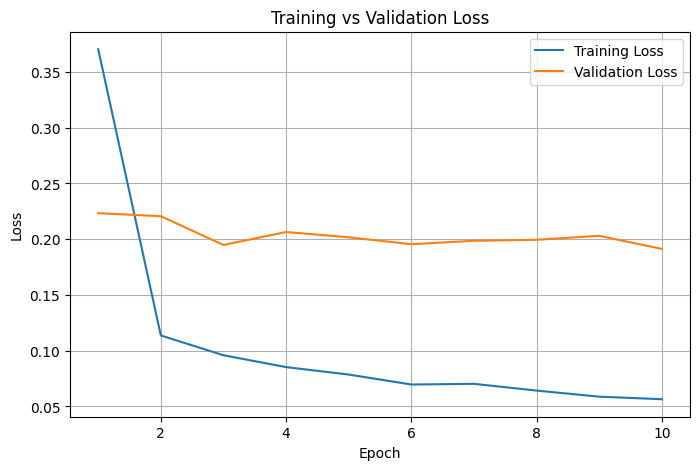

In [35]:
# ============================================================
# Phase 19: Training Curves
# ============================================================

import matplotlib.pyplot as plt

# Assuming train_losses and val_losses are available from the training loop
# If a kernel restart occurred, these might be undefined and will raise a NameError.
epochs = range(1, len(train_losses) + 1)

# ------------------------------------------------------------
# Loss
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_losses,
    label="Training Loss"
)

plt.plot(
    epochs,
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid()

plt.show()

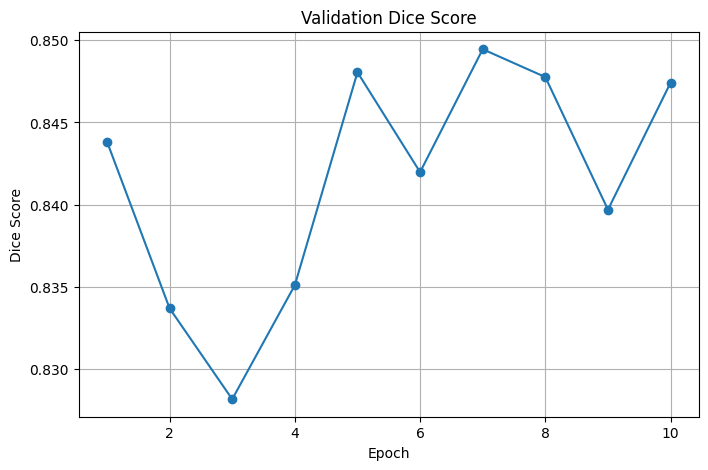

In [36]:
# ============================================================
# Validation Dice Score
# ============================================================

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    val_dice_scores,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.title("Validation Dice Score")
plt.grid()

plt.show()

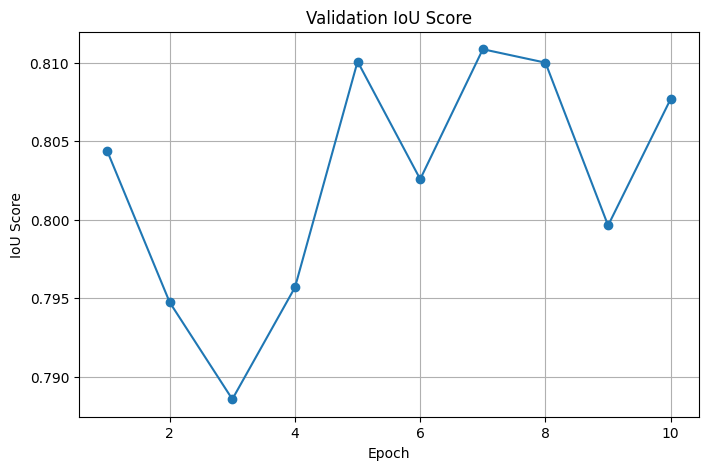

In [37]:
# ============================================================
# Validation IoU Score
# ============================================================

import matplotlib.pyplot as plt

# Assuming val_iou_scores is available from the training loop
# If a kernel restart occurred, this might be undefined and will raise a NameError.
epochs = range(1, len(val_iou_scores) + 1)

plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    val_iou_scores,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("IoU Score")
plt.title("Validation IoU Score")
plt.grid()

plt.show()

In [38]:
# ============================================================
# Phase 19: Load Best Model
# ============================================================

import torch
import segmentation_models_pytorch as smp
import os

# Re-initialize device and model as they might be undefined
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=1,
    classes=1
)
model = model.to(device)

model_path = "best_brain_tumor_unet.pth"

if not os.path.exists(model_path):
    print(f"Error: Model weights file '{model_path}' not found. Please ensure the training loop (Phase 18) was executed successfully and saved the model.")
else:
    model.load_state_dict(
        torch.load(
            model_path,
            map_location=device
        )
    )

    model.to(device)

    print("Best model loaded.")
    if 'best_val_dice' in globals():
        print("Best validation Dice:", best_val_dice)
    else:
        print("Warning: 'best_val_dice' variable not found. Please ensure the training loop (Phase 18) was executed.")

Best model loaded.
Best validation Dice: 0.8494464243370831


In [39]:
# ============================================================
# Phase 20: Test Set Evaluation
# ============================================================

import torch
import segmentation_models_pytorch as smp
import os

# Re-initialize device and model for robustness
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=1,
    classes=1
)
model = model.to(device)

model_path = "best_brain_tumor_unet.pth"
if not os.path.exists(model_path):
    print(f"Error: Model weights file '{model_path}' not found. Cannot perform test set evaluation. Please ensure the training loop (Phase 18) was executed successfully and saved the model.")
elif 'test_loader' not in globals():
    print("Error: 'test_loader' not found. Please ensure the DataLoader creation cell (Phase 8/9) was executed.")
else:
    # Load the best model weights if they exist (assuming previous cell handled the loading)
    # If this cell is run independently after a kernel restart, uncomment the following line:
    # model.load_state_dict(torch.load(model_path, map_location=device))

    model.eval()

    test_loss = 0.0
    test_dice = 0.0
    test_iou = 0.0

    with torch.no_grad():

        for images, masks in test_loader:

            images = images.to(device)
            masks = masks.to(device)

            predictions = model(images)

            loss = loss_function(
                predictions,
                masks
            )

            dice = dice_score(
                predictions,
                masks
            )

            iou = iou_score(
                predictions,
                masks
            )

            test_loss += loss.item()
            test_dice += dice.item()
            test_iou += iou.item()


    test_loss /= len(test_loader)
    test_dice /= len(test_loader)
    test_iou /= len(test_loader)


    print("Test Loss:", test_loss)
    print("Test Dice:", test_dice)
    print("Test IoU:", test_iou)

Test Loss: 1.3783667275700906
Test Dice: 0.01815374462333423
Test IoU: 0.009409743801910073
